In [1]:
# ======================================
# 0. Core libs (DAY1~DAY9 공통)
# ======================================
import numpy as np
import pandas as pd

import shutil
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import matplotlib.font_manager as fm
from matplotlib import rcParams

# ======================================
# 1) Style FIRST (폰트보다 먼저)
# ======================================
plt.style.use("_mpl-gallery-nogrid")
sns.set_theme(style="white")
sns.set_style("ticks")
sns.set_context("notebook")

# ======================================
# 2) Font (NanumGothic) — style 적용 후 "고정"
# ======================================
FONT_DIR = Path(r"C:\Users\danawa\Desktop\Portfolio\Portfolio_ver1\fonts")
FONT_PATH = FONT_DIR / "NanumGothic.ttf"

if not FONT_PATH.exists():
    raise FileNotFoundError(f"폰트 파일 없음: {FONT_PATH}")

fm.fontManager.addfont(str(FONT_PATH))
font_name = fm.FontProperties(fname=str(FONT_PATH)).get_name()

rcParams["font.family"] = font_name
rcParams["axes.unicode_minus"] = False

# (선택) 기본 글자 크기 통일
rcParams["font.size"] = 12
rcParams["axes.titlesize"] = 18
rcParams["axes.labelsize"] = 14
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 12

# 개별 객체용 (필요할 때만)
font_prop = fm.FontProperties(fname=str(FONT_PATH))

print("✅ Style+Font ready:", font_name)

✅ Style+Font ready: NanumGothic


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. 데이터 불러오기
power_path = r'C:\Users\danawa\Desktop\Portfolio\Portfolio_ver1\data\2024년 연료원별 시간대별 설비용량 및 전력거래량.xlsx'
weather_path = r'C:\Users\danawa\Desktop\Portfolio\Portfolio_ver1\data\OBS_ASOS_TIM_20260101131730.csv'

df_power_raw = pd.read_excel(power_path, skiprows=5)
df_weather_raw = pd.read_csv(weather_path, encoding='cp949') # 또는 'cp949'

# 2. 기상 데이터: 전국 평균(National Average) 계산
# 컬럼 이름이 깨질 수 있으므로 위치(Index)로 이름을 먼저 바꿉니다.
df_weather = df_weather_raw.rename(columns={
    df_weather_raw.columns[2]: '일시',
    df_weather_raw.columns[3]: '기온',
    df_weather_raw.columns[9]: '일사'
})
df_weather['일시'] = pd.to_datetime(df_weather['일시'])

# [핵심] 전국 모든 지점의 날씨를 시간별로 평균 냅니다.
df_weather_nat = df_weather.groupby('일시')[['기온', '일사']].mean().reset_index()
df_weather_nat['일사'] = df_weather_nat['일사'].fillna(0)

# 3. 전력 데이터 전처리
df_power_raw['일시'] = pd.to_datetime(df_power_raw['거래일자'].astype(str)) + pd.to_timedelta(df_power_raw['시간'] - 1, unit='h')
df_solar = df_power_raw[df_power_raw['원료원'] == '태양광'].copy().rename(columns={'전력거래량(MWh)': 'solar_gen'})
df_total = df_power_raw.groupby('일시')['전력거래량(MWh)'].sum().reset_index().rename(columns={'전력거래량(MWh)': 'total_load'})

# 4. 데이터 머지 (전국 기상 평균 + 전국 전력 데이터)
df_merged = pd.merge(df_total, df_solar[['일시', 'solar_gen']], on='일시')
df_merged = pd.merge(df_merged, df_weather_nat, on='일시', how='left')

# 파생 변수 생성
df_merged['net_load'] = df_merged['total_load'] - df_merged['solar_gen']
df_merged['hour'] = df_merged['일시'].dt.hour
df_merged['date_str'] = df_merged['일시'].dt.strftime('%Y%m%d')

print("✅ Step 1: 전국 데이터 머지 완료!")

✅ Step 1: 전국 데이터 머지 완료!


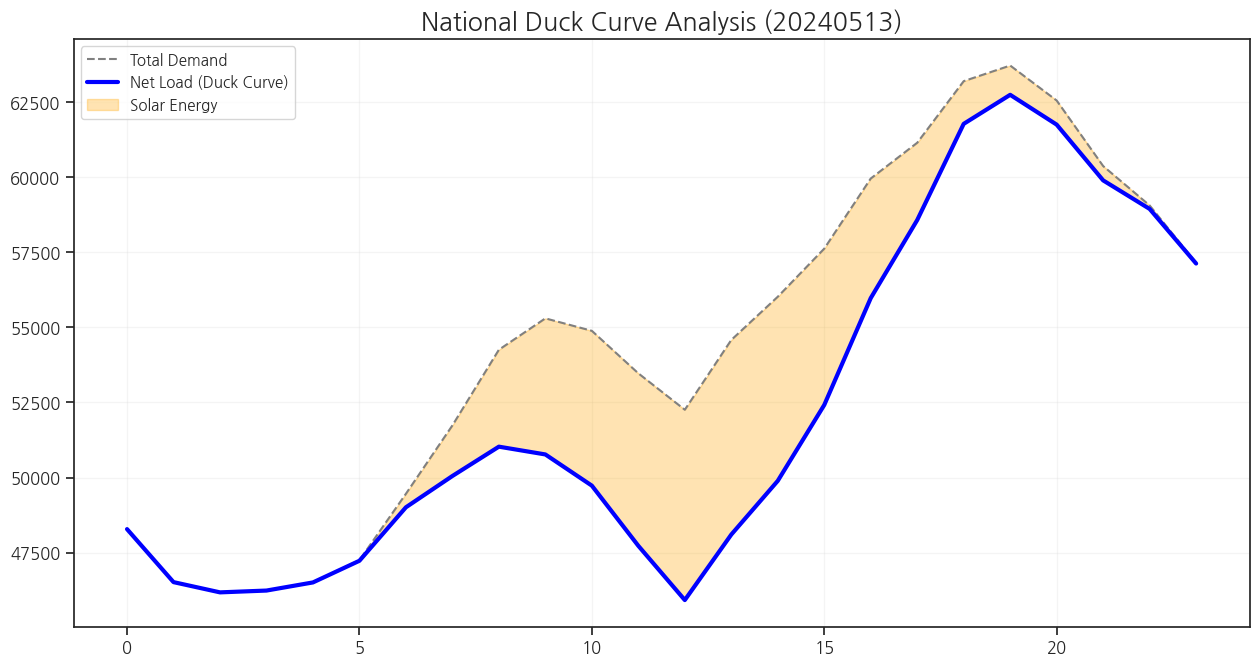

In [4]:
# 5. 시각화 (전국 단위 덕 커브)
target_day = '20240513'
day_df = df_merged[df_merged['date_str'] == target_day].sort_values('hour')

plt.figure(figsize=(12, 6))
plt.plot(day_df['hour'], day_df['total_load'], label='Total Demand', color='gray', linestyle='--')
plt.plot(day_df['hour'], day_df['net_load'], label='Net Load (Duck Curve)', color='blue', linewidth=3)
plt.fill_between(day_df['hour'], day_df['net_load'], day_df['total_load'], color='orange', alpha=0.3, label='Solar Energy')
plt.title(f'National Duck Curve Analysis ({target_day})')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [5]:
# 6. AI 모델링 및 잉여 에너지 산출
X = df_merged[['hour', '일사', '기온']].dropna()
y = df_merged.loc[X.index, 'solar_gen']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
surplus = day_df[(day_df['hour'] >= 9) & (day_df['hour'] <= 16)]['solar_gen'].sum()

print(f"✅ Step 2: AI 예측 오차(MAE): {mean_absolute_error(y_test, y_pred):.2f} MWh")
print(f"✅ Step 3: {target_day} 전국 잉여 에너지: {surplus:.2f} MWh")

✅ Step 2: AI 예측 오차(MAE): 154.49 MWh
✅ Step 3: 20240513 전국 잉여 에너지: 43578.94 MWh


In [6]:
# ==========================================
# [Step 2] 배터리(ESS) 경제성 시뮬레이션
# ==========================================

# 1번에서 구한 잉여 에너지 (MWh)
surplus_mwh = 43578.94 

# 배터리 스펙 설정
specs = {
    'Lithium-ion': {
        'efficiency': 0.95,      # 충방전 효율 95%
        'cost_per_kwh': 150,     # 1kWh당 설치 비용 ($)
        'dod': 0.90              # 방전 깊이 (배터리 용량의 90%만 사용 가능)
    },
    'Sodium-ion': {
        'efficiency': 0.88,      # 충방전 효율 88%
        'cost_per_kwh': 80,      # 1kWh당 설치 비용 ($)
        'dod': 0.95              # 방전 깊이 (배터리 용량의 95%까지 사용 가능)
    }
}

results = []

for name, spec in specs.items():
    # 필요 배터리 용량 (MWh) = 잉여 에너지 / 방전깊이
    required_capacity = surplus_mwh / spec['dod']
    
    # 실제로 나중에 꺼내 쓸 수 있는 에너지 (MWh) = 잉여 에너지 * 효율
    recovered_energy = surplus_mwh * spec['efficiency']
    
    # 총 설치 비용 (백만 달러) = 용량(kWh) * 단가 / 1000
    total_cost_million = (required_capacity * 1000 * spec['cost_per_kwh']) / 1_000_000
    
    results.append({
        '배터리 종류': name,
        '필요 용량(MWh)': round(required_capacity, 2),
        '회수 에너지(MWh)': round(recovered_energy, 2),
        '예상 설치비(M$ )': round(total_cost_million, 2)
    })

# 결과 출력
df_ess = pd.DataFrame(results)
print("-" * 50)
print("🔋 배터리 기술별 도입 시뮬레이션 결과")
print(df_ess)
print("-" * 50)

--------------------------------------------------
🔋 배터리 기술별 도입 시뮬레이션 결과
        배터리 종류  필요 용량(MWh)  회수 에너지(MWh)  예상 설치비(M$ )
0  Lithium-ion    48421.04     41399.99      7263.16
1   Sodium-ion    45872.57     38349.47      3669.81
--------------------------------------------------


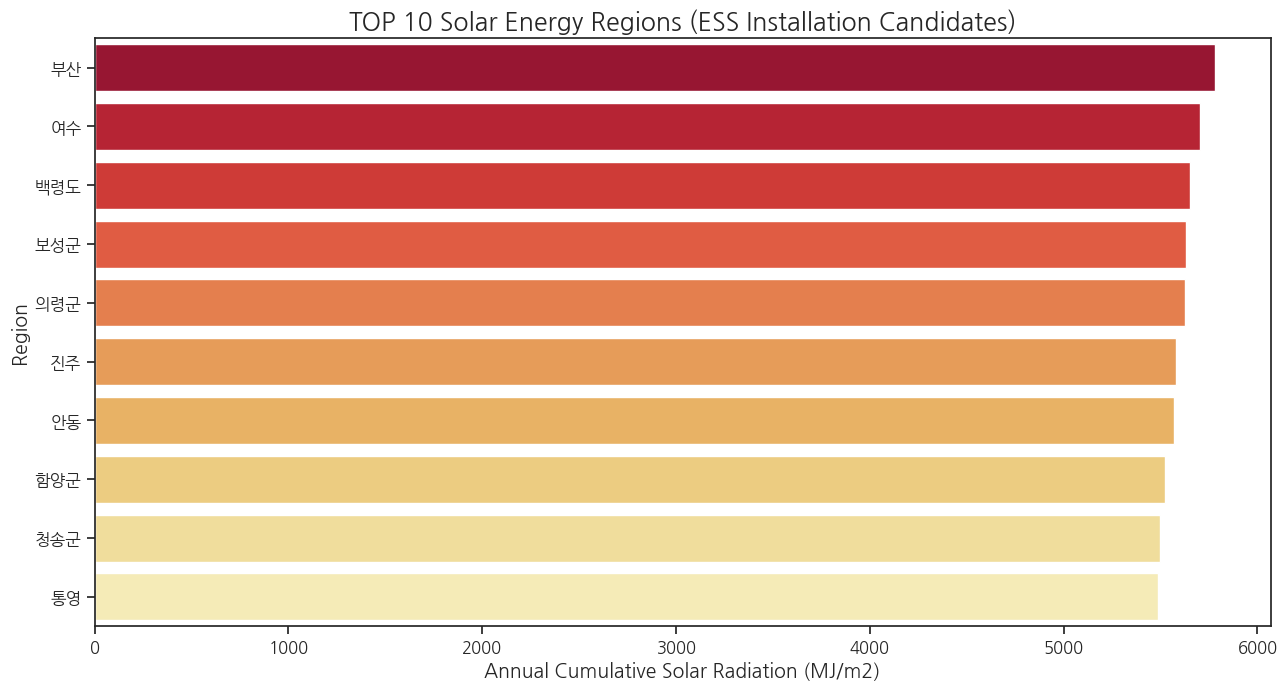

✅ Step 3: 최적 입지 선정 분석 완료!


In [7]:
# ==========================================
# [Step 3] 전국 일사량 데이터 기반 최적 입지 선정 (수정 버전)
# ==========================================

# 1. 일사량이 높은 순서대로 정렬 (TOP 10)
top_locations = df_weather.groupby('지점명')['일사'].sum().reset_index().sort_values(by='일사', ascending=False).head(10)

# 2. 시각화 (경고 해결 버전)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_locations, 
    x='일사', 
    y='지점명', 
    hue='지점명',      # hue에 변수를 할당해서 경고 해결
    palette='YlOrRd_r', 
    legend=False       # 범례는 숨김
)
plt.title('TOP 10 Solar Energy Regions (ESS Installation Candidates)')
plt.xlabel('Annual Cumulative Solar Radiation (MJ/m2)')
plt.ylabel('Region')
plt.show()

print("✅ Step 3: 최적 입지 선정 분석 완료!")

In [8]:
import folium

# 1. 쟈기님이 찾은 지역들의 위도/경도 데이터 (주요 지점 좌표)
locations = {
    '부산': [35.1796, 129.0756],
    '여수': [34.7604, 127.6622],
    '백령도': [37.9465, 124.6300],
    '보성군': [34.7701, 127.0797],
    '의령군': [35.3221, 128.2612],
    '진주': [35.1795, 128.1076],
    '안동': [36.5684, 128.7294], 
    '함양군': [35.5205, 127.7252], 
    '청송군': [36.4355, 129.0573], 
    '통영': [34.8544, 128.4331]
}

# 2. 지도 생성 (대한민국 중심 좌표로 시작)
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

# 3. 각 지역에 배터리 스테이션 후보지 마커 찍기
for name, coord in locations.items():
    folium.Marker(
        location=coord,
        popup=f"<b>{name}</b><br>ESS 최적 후보지",
        tooltip=name,
        icon=folium.Icon(color='red', icon='bolt', prefix='fa') # 번개 모양 아이콘
    ).add_to(m)

    # 시각적 효과를 위해 반경 표시 (일사량 영향권 예시)
    folium.Circle(
        location=coord,
        radius=20000, # 20km 반경
        color='red',
        fill=True,
        fill_opacity=0.2
    ).add_to(m)

# 4. 지도 저장
m.save('ess_location_map_ver1.html')

print("✅ Step 4: 지도 시각화 완성!")
print("👉 'ess_location_map_ver1.html' 파일을 열면 브라우저에서 멋진 지도를 볼 수 있어요!")

✅ Step 4: 지도 시각화 완성!
👉 'ess_location_map_ver1.html' 파일을 열면 브라우저에서 멋진 지도를 볼 수 있어요!


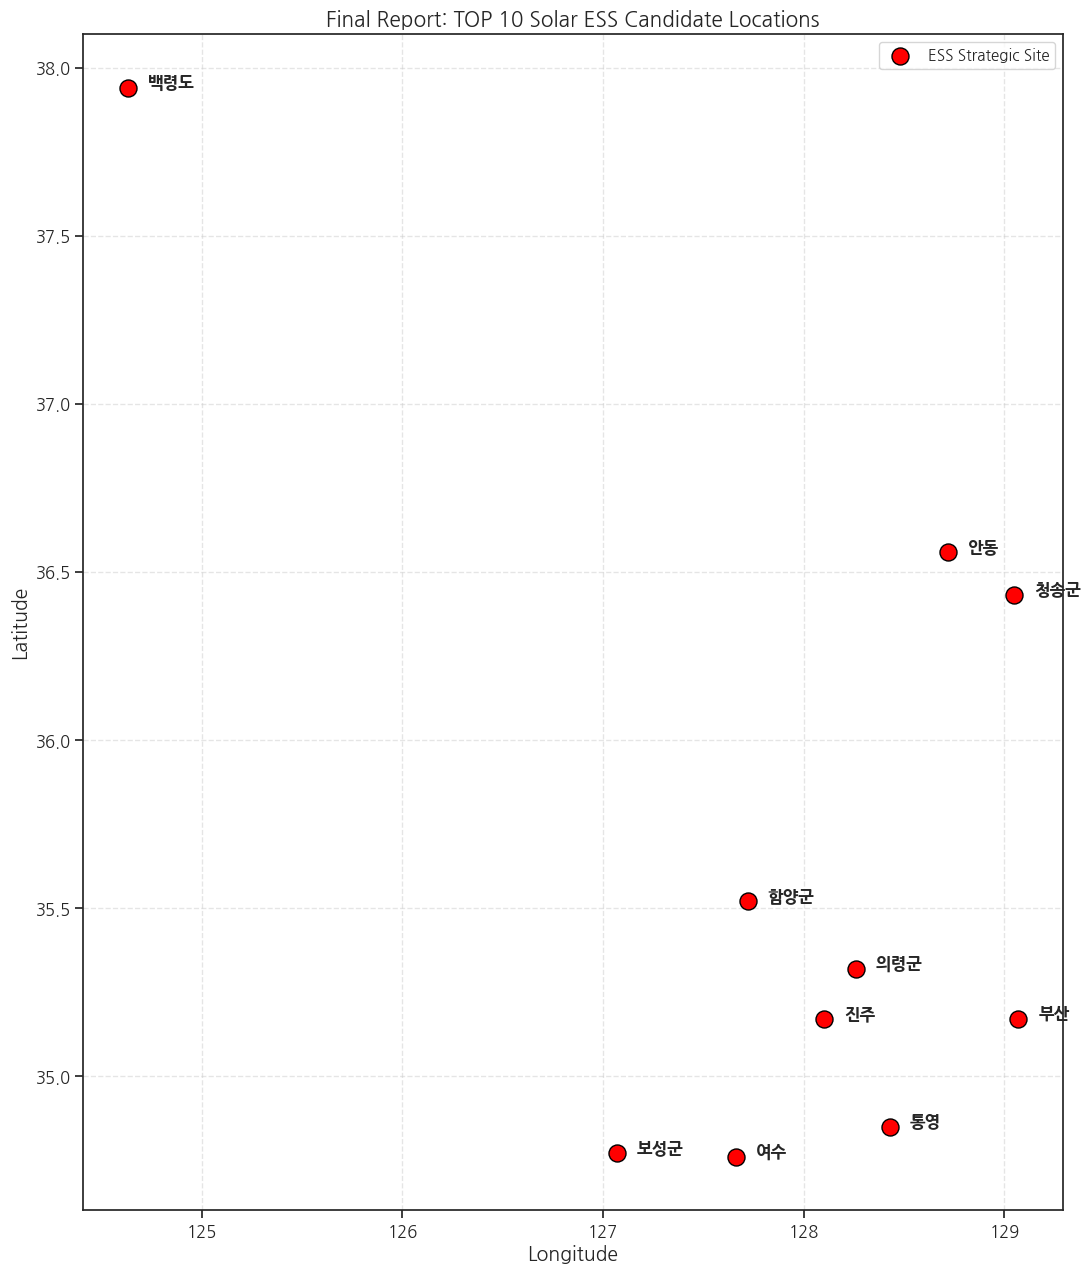

🏆 [최종 결론] 차세대 나트륨 배터리(SIB) 기반 에너지 벨트 제안
대상 지역: 부산, 여수, 백령도, 보성군, 의령군, 진주, 안동, 함양군, 청송군, 통영
전략: 위 10개 지역에 집중적으로 SIB ESS를 구축하여 연간 약 43,578MWh의 버려지는 에너지를 회수함.


In [9]:
# 1. 쟈기님이 완성해주신 TOP 10 지역과 좌표 (Lon, Lat)
top_10_locations = {
    '부산': (129.07, 35.17), '여수': (127.66, 34.76), 
    '백령도': (124.63, 37.94), '보성군': (127.07, 34.77), 
    '의령군': (128.26, 35.32), '진주': (128.10, 35.17),
    '안동': (128.72, 36.56), '함양군': (127.72, 35.52), 
    '청송군': (129.05, 36.43), '통영': (128.43, 34.85)
}

# 2. 시각화 (위도/경도 평면도)
lons = [v[0] for v in top_10_locations.values()]
lats = [v[1] for v in top_10_locations.values()]
names = list(top_10_locations.keys())

plt.figure(figsize=(10, 12))
plt.scatter(lons, lats, color='red', s=150, edgecolors='black', label='ESS Strategic Site')

for i, name in enumerate(names):
    plt.text(lons[i] + 0.1, lats[i], name, fontsize=12, fontweight='bold')

plt.title('Final Report: TOP 10 Solar ESS Candidate Locations', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print("="*50)
print("🏆 [최종 결론] 차세대 나트륨 배터리(SIB) 기반 에너지 벨트 제안")
print(f"대상 지역: {', '.join(names)}")
print("전략: 위 10개 지역에 집중적으로 SIB ESS를 구축하여 연간 약 43,578MWh의 버려지는 에너지를 회수함.")
print("="*50)

In [10]:
import folium
import os
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

# 1. 아까 만든 지도 생성 코드 (동일하게)
locations = {
    '부산': [35.1796, 129.0756], '여수': [34.7604, 127.6622],
    '백령도': [37.9465, 124.6300], '보성군': [34.7701, 127.0797],
    '의령군': [35.3221, 128.2612], '진주': [35.1795, 128.1076],
    '안동': [36.5684, 128.7294], '함양군': [35.5205, 127.7252],
    '청송군': [36.4355, 129.0573], '통영': [34.8544, 128.4331]
}

m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

for name, coord in locations.items():
    folium.Marker(location=coord, tooltip=name,
                  icon=folium.Icon(color='red', icon='bolt', prefix='fa')).add_to(m)
    folium.Circle(location=coord, radius=20000, color='red', fill=True, fill_opacity=0.2).add_to(m)

# 2. 먼저 HTML로 저장
html_file = 'ess_map.html'
m.save(html_file)

# 3. Selenium을 이용해 HTML을 열고 스크린샷 찍기
options = webdriver.ChromeOptions()
options.add_argument('--headless') # 브라우저 창을 띄우지 않고 실행
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# 파일 경로를 브라우저가 읽을 수 있는 형태로 변환
tmp_url = 'file://{path}/{mapfile}'.format(path=os.getcwd(), mapfile=html_file)
driver.get(tmp_url)

# 지도가 로딩될 때까지 잠시 대기 (2~3초)
time.sleep(3)

# PNG로 저장
driver.save_screenshot('ess_final_map.png')
driver.quit()

print("✅ 폴리움 지도가 'ess_final_map.png'로 저장되었습니다!")

✅ 폴리움 지도가 'ess_final_map.png'로 저장되었습니다!


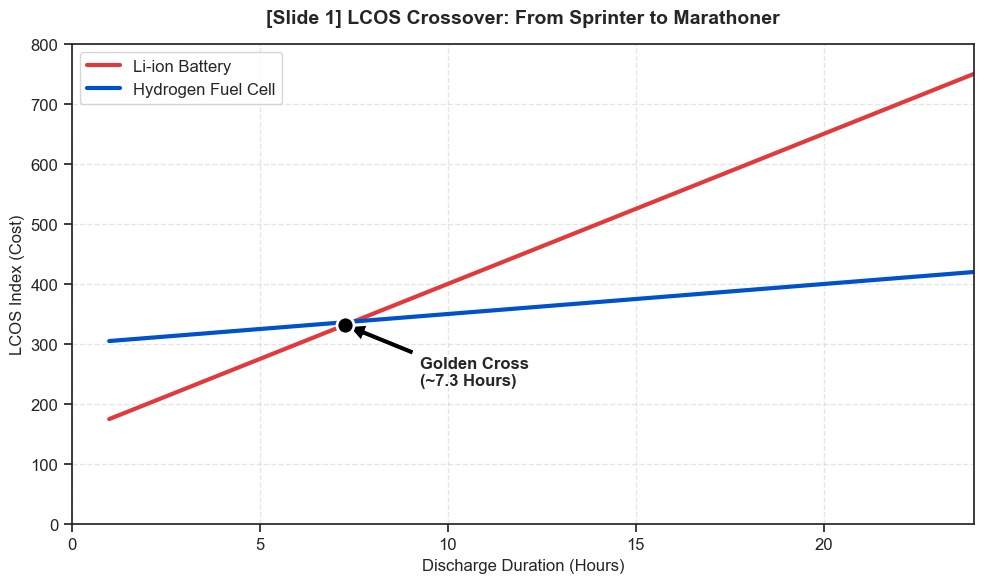

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


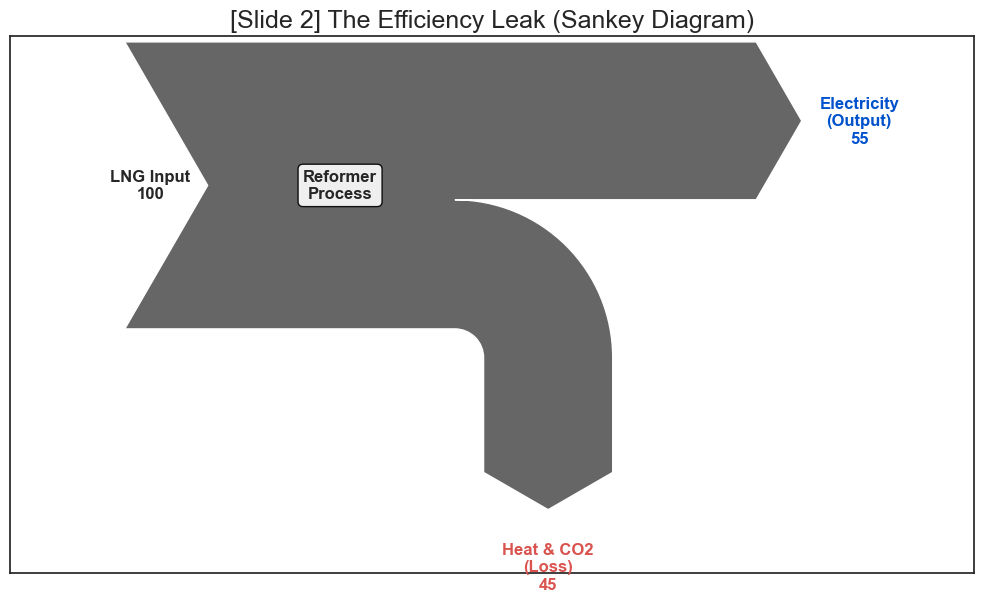

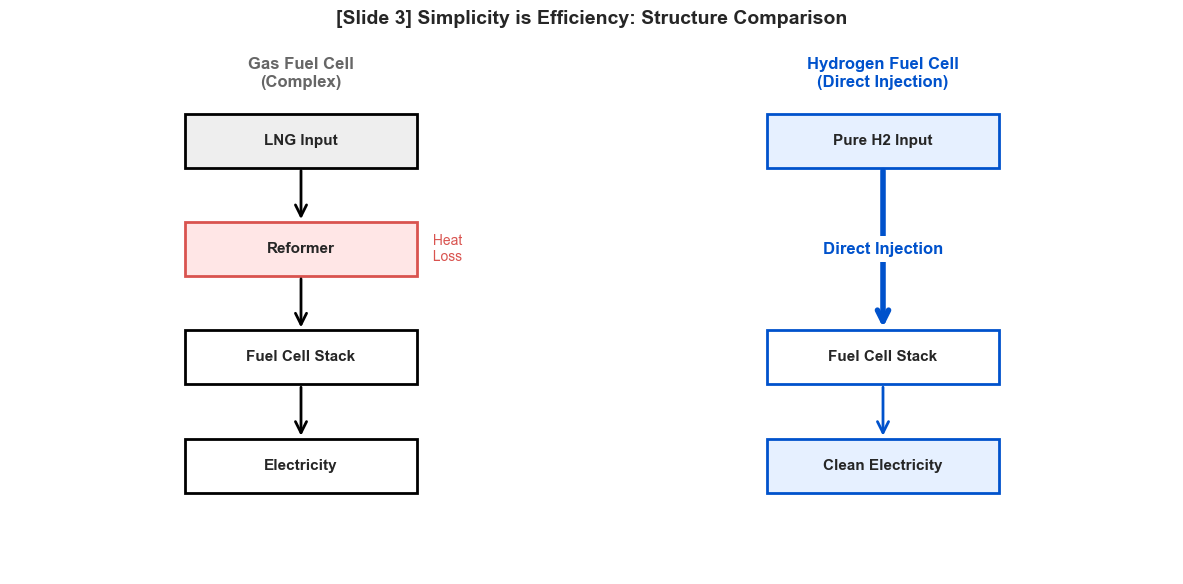

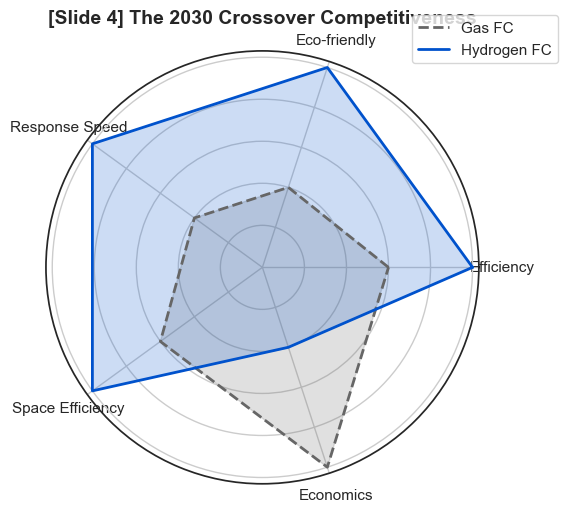

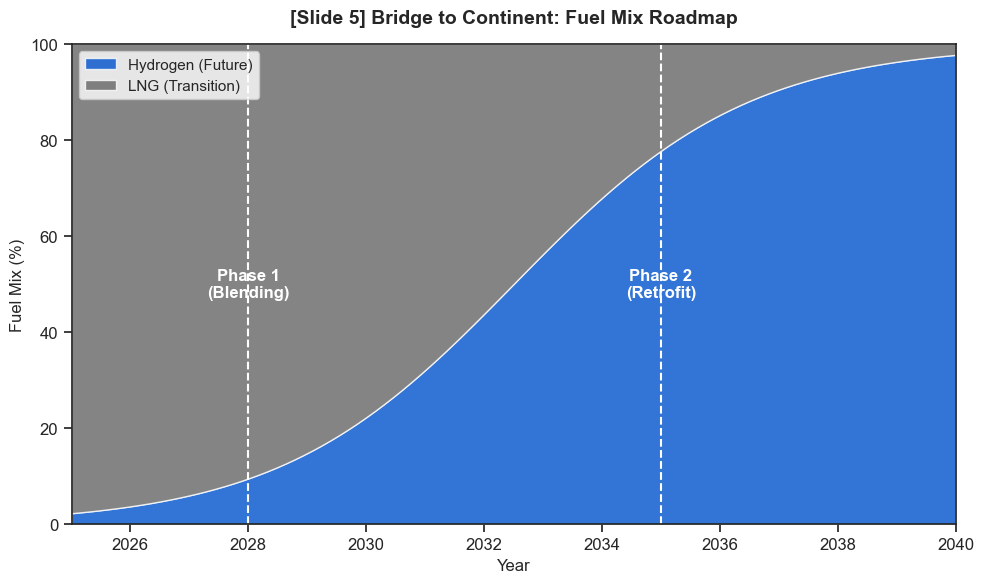

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.sankey import Sankey
from matplotlib.patches import Rectangle, FancyArrowPatch, BoxStyle
import matplotlib.patheffects as path_effects

# 공통 스타일 설정
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 색상 팔레트
COLOR_GAS = '#666666'      # 짙은 회색 (가스)
COLOR_H2 = '#0052CC'       # 밝은 파란색 (수소)
COLOR_LI = '#E03A3C'       # 빨간색 (배터리)
COLOR_LOSS = '#D9534F'     # 손실 (빨간색 계열)

# ---------------------------------------------------------
# Slide 1: LCOS Crossover Chart (Line Chart)
# ---------------------------------------------------------
def draw_slide1_lcos():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    duration = np.linspace(1, 24, 100)
    lcos_li = 150 + (duration * 25)   # 배터리 (기울기 급함)
    lcos_fc = 300 + (duration * 5)    # 연료전지 (기울기 완만)
    
    ax.plot(duration, lcos_li, label='Li-ion Battery', color=COLOR_LI, linewidth=3)
    ax.plot(duration, lcos_fc, label='Hydrogen Fuel Cell', color=COLOR_H2, linewidth=3)
    
    # Golden Cross
    cross_idx = np.argwhere(np.diff(np.sign(lcos_li - lcos_fc))).flatten()
    if len(cross_idx) > 0:
        cx, cy = duration[cross_idx[0]], lcos_li[cross_idx[0]]
        ax.scatter(cx, cy, color='black', s=150, zorder=5, edgecolor='white', linewidth=2)
        ax.annotate(f'Golden Cross\n(~{cx:.1f} Hours)', (cx, cy), xytext=(cx+2, cy-100),
                    arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')
    
    ax.set_title('[Slide 1] LCOS Crossover: From Sprinter to Marathoner', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Discharge Duration (Hours)', fontsize=12)
    ax.set_ylabel('LCOS Index (Cost)', fontsize=12)
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 800)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Slide 2: Sankey Diagram (Energy Flow)
# ---------------------------------------------------------
def draw_slide2_sankey():
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, xticks=[], yticks=[], title="[Slide 2] The Efficiency Leak (Sankey Diagram)")
    
    sankey = Sankey(ax=ax, scale=0.01, offset=0.2, head_angle=120, margin=0.4, shoulder=0)
    
    # LNG -> Reformer -> (Electricity, Loss)
    sankey.add(flows=[100, -55, -45],
               labels=['LNG Input', 'Electricity\n(Output)', 'Heat & CO2\n(Loss)'],
               orientations=[0, 0, -1],
               pathlengths=[0.5, 0.5, 0.5],
               facecolor=COLOR_GAS,
               edgecolor='white')
    
    diagrams = sankey.finish()
    
    # 색상 커스터마이징 (출력: 파랑, 손실: 빨강)
    diagrams[0].texts[0].set_fontweight('bold') # Input
    diagrams[0].texts[1].set_color(COLOR_H2)    # Elec
    diagrams[0].texts[1].set_fontweight('bold')
    diagrams[0].texts[2].set_color(COLOR_LOSS)  # Loss
    diagrams[0].texts[2].set_fontweight('bold')
    
    # 개질기(Reformer) 박스 표시
    # Sankey 좌표계가 복잡하므로 텍스트로 보완
    plt.text(0, 0, "Reformer\nProcess", ha='center', va='center', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9), fontweight='bold')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Slide 3: Structure Comparison (Schematic)
# ---------------------------------------------------------
def draw_slide3_structure():
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')
    ax.set_title("[Slide 3] Simplicity is Efficiency: Structure Comparison", fontsize=14, fontweight='bold')
    
    # Helper to draw box
    def draw_process_box(x, y, text, color='white', edge='black'):
        rect = Rectangle((x, y), 1.5, 1, facecolor=color, edgecolor=edge, linewidth=2)
        ax.add_patch(rect)
        ax.text(x + 0.75, y + 0.5, text, ha='center', va='center', fontsize=11, fontweight='bold')

    # Helper to draw arrow
    def draw_arrow(x1, y1, x2, y2, color='black'):
        arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=20, color=color, linewidth=2)
        ax.add_patch(arrow)

    # --- LEFT: Gas FC (Complex) ---
    ax.text(2.5, 5.5, "Current: Gas Fuel Cell", ha='center', fontsize=13, fontweight='bold', color=COLOR_GAS)
    
    draw_process_box(0.5, 4, "LNG", color='#EEEEEE')
    draw_arrow(2.0, 4.5, 2.5, 4.5)
    
    draw_process_box(2.5, 4, "Reformer", color='#FFE6E6', edge=COLOR_LOSS) # 개질기 강조
    ax.text(3.25, 3.8, "Loss/CO2", ha='center', va='top', color=COLOR_LOSS, fontsize=9)
    draw_arrow(4.0, 4.5, 4.5, 4.5)
    
    draw_process_box(4.5, 4, "Stack")
    draw_arrow(5.0, 4.0, 5.0, 3.5) # Down arrow to power? No, let's go right
    # Layout adjustment for comparison, let's keep it linear for simplicity or vertical.
    # Let's do vertical flow for better comparison? No, horizontal is fine.
    # Actually, diagram blueprint said vertical. Let's do Vertical.
    
    # REDRAWING VERTICAL based on user request blueprint
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title("[Slide 3] Simplicity is Efficiency: Structure Comparison", fontsize=14, fontweight='bold')
    
    def draw_v_box(x, y, text, color='white', edge='black'):
        rect = Rectangle((x-1, y-0.5), 2, 1, facecolor=color, edgecolor=edge, linewidth=2)
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center', fontsize=11, fontweight='bold')
        
    def draw_v_arrow(x, y_start, y_end, color='black', width=2):
        arrow = FancyArrowPatch((x, y_start), (x, y_end), arrowstyle='->', mutation_scale=20, color=color, linewidth=width)
        ax.add_patch(arrow)

    # Left: Gas
    ax.text(2.5, 9, "Gas Fuel Cell\n(Complex)", ha='center', fontsize=12, fontweight='bold', color=COLOR_GAS)
    draw_v_box(2.5, 8, "LNG Input", color='#EEEEEE')
    draw_v_arrow(2.5, 7.5, 6.5)
    
    draw_v_box(2.5, 6, "Reformer", color='#FFE6E6', edge=COLOR_LOSS) # Problem area
    ax.text(3.6, 6, " Heat\n Loss", color=COLOR_LOSS, fontsize=10, ha='left', va='center')
    draw_v_arrow(2.5, 5.5, 4.5)
    
    draw_v_box(2.5, 4, "Fuel Cell Stack")
    draw_v_arrow(2.5, 3.5, 2.5)
    
    draw_v_box(2.5, 2, "Electricity")

    # Right: H2
    ax.text(7.5, 9, "Hydrogen Fuel Cell\n(Direct Injection)", ha='center', fontsize=12, fontweight='bold', color=COLOR_H2)
    draw_v_box(7.5, 8, "Pure H2 Input", color='#E6F0FF', edge=COLOR_H2)
    
    # Direct Injection Arrow (Bold & Blue)
    draw_v_arrow(7.5, 7.5, 4.5, color=COLOR_H2, width=4) 
    ax.text(7.5, 6, "Direct Injection", color=COLOR_H2, fontweight='bold', ha='center', va='center', bbox=dict(fc='white', ec='none'))
    
    draw_v_box(7.5, 4, "Fuel Cell Stack", edge=COLOR_H2)
    draw_v_arrow(7.5, 3.5, 2.5, color=COLOR_H2)
    
    draw_v_box(7.5, 2, "Clean Electricity", color='#E6F0FF', edge=COLOR_H2)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Slide 4: Radar Chart
# ---------------------------------------------------------
def draw_slide4_radar():
    labels = ['Efficiency', 'Eco-friendly', 'Response Speed', 'Space Efficiency', 'Economics']
    stats_gas = [3, 2, 2, 3, 5] 
    stats_h2 =  [5, 5, 5, 5, 2] 
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    stats_gas += stats_gas[:1]
    stats_h2 += stats_h2[:1]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, stats_gas, color=COLOR_GAS, linewidth=2, linestyle='--', label='Gas FC')
    ax.fill(angles, stats_gas, color=COLOR_GAS, alpha=0.2)
    
    ax.plot(angles, stats_h2, color=COLOR_H2, linewidth=2, label='Hydrogen FC')
    ax.fill(angles, stats_h2, color=COLOR_H2, alpha=0.2)
    
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
    ax.set_title('[Slide 4] The 2030 Crossover Competitiveness', fontsize=14, fontweight='bold', pad=20)
    ax.set_yticklabels([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Slide 5: Roadmap (Stacked Area)
# ---------------------------------------------------------
def draw_slide5_roadmap():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.linspace(2025, 2040, 100)
    y_h2 = 100 / (1 + np.exp(-0.5 * (x - 2032.5))) 
    y_gas = 100 - y_h2
    
    ax.stackplot(x, y_h2, y_gas, labels=['Hydrogen (Future)', 'LNG (Transition)'], 
                 colors=[COLOR_H2, COLOR_GAS], alpha=0.8)
    
    phases = {2028: 'Phase 1\n(Blending)', 2035: 'Phase 2\n(Retrofit)'}
    for year, text in phases.items():
        ax.axvline(x=year, color='white', linestyle='--', linewidth=1.5)
        ax.text(year, 50, text, color='white', ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_title('[Slide 5] Bridge to Continent: Fuel Mix Roadmap', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Fuel Mix (%)', fontsize=12)
    ax.set_xlim(2025, 2040)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# 실행
draw_slide1_lcos()
draw_slide2_sankey()
draw_slide3_structure()
draw_slide4_radar()
draw_slide5_roadmap()

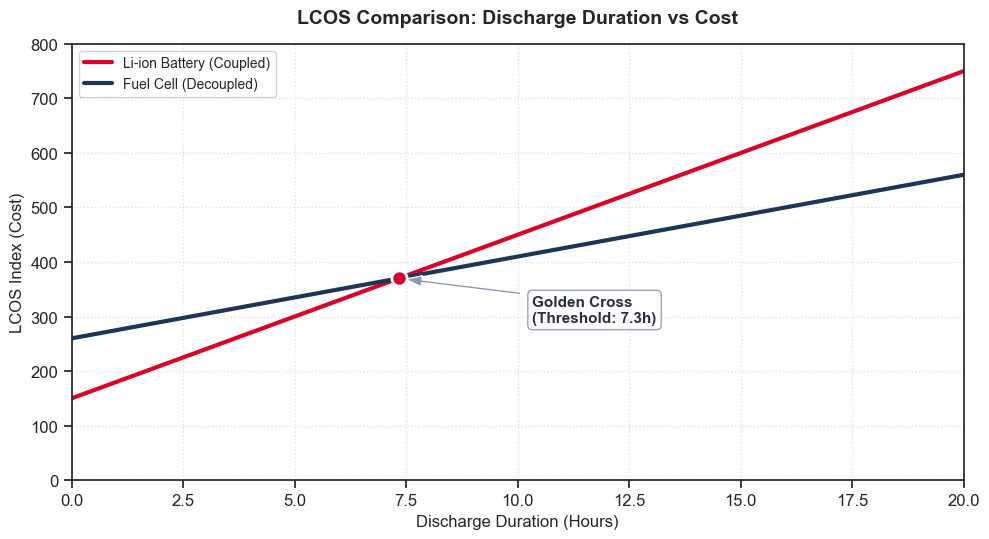

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정 (논리적 정합성을 위해 7.3시간에 교차하도록 설정)
hours = np.linspace(0, 24, 100)
# 배터리: 초기비용 낮음(150), 시간당 비용 상승 큼(30) -> 기울기 급함
lcos_battery = 150 + 30 * hours
# 연료전지: 초기비용 높음(260), 시간당 비용 상승 작음(15) -> 기울기 완만
# 교차점 계산: 150 + 30x = 260 + 15x  -> 15x = 110 -> x = 7.33
lcos_fuelcell = 260 + 15 * hours

# 7.3시간 지점 좌표 (Golden Cross)
cross_x = 7.33
cross_y = 150 + 30 * cross_x

# 그래프 스타일 설정 (포트폴리오 톤앤매너: 깔끔, 전문적)
plt.figure(figsize=(10, 5.5)) # Slide 19의 좌측 영역 비율 고려
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# 1. 라인 그리기
# 배터리: 붉은 계열 (경고, 비용 급증 느낌)
plt.plot(hours, lcos_battery, label='Li-ion Battery (Coupled)', color='#D90429', linewidth=3)
# 연료전지: 푸른 계열 (안정, 솔루션 느낌)
plt.plot(hours, lcos_fuelcell, label='Fuel Cell (Decoupled)', color='#1D3557', linewidth=3)

# 2. Golden Cross 포인트 (Anchor Point 스타일)
plt.scatter(cross_x, cross_y, color='#D90429', s=120, zorder=5, edgecolors='white', linewidth=2)

# 3. 화살표 및 텍스트 (Slide 19의 붉은 화살표 스타일 재현)
plt.annotate(f'Golden Cross\n(Threshold: {cross_x:.1f}h)',
             xy=(cross_x, cross_y),
             xytext=(cross_x + 3, cross_y - 80),
             arrowprops=dict(facecolor='#8D99AE', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='#2B2D42',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#8D99AE", alpha=0.9))

# 4. 축 및 그리드 설정
plt.title('LCOS Comparison: Discharge Duration vs Cost', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discharge Duration (Hours)', fontsize=12)
plt.ylabel('LCOS Index (Cost)', fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 800)

# 깔끔한 그리드 (회색 점선)
plt.grid(True, linestyle=':', alpha=0.6)

# 범례
plt.legend(loc='upper left', fontsize=10, frameon=True, framealpha=1, edgecolor='lightgray')

plt.tight_layout()
plt.savefig('slide1_lcos_graph.png', dpi=300) # 고화질 저장
plt.show()

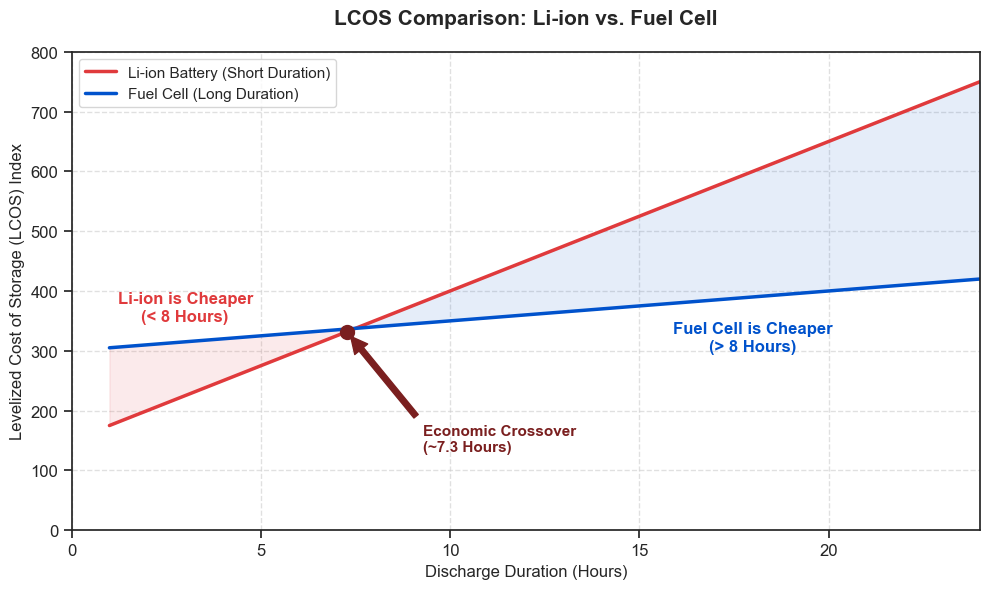

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성 (가상의 LCOS 곡선)
duration = np.linspace(1, 24, 100)  # 방전 지속 시간 (1~24시간)

# Li-ion (배터리): 초기 비용 낮음, 시간 증가에 따라 비용 급증 (기울기 가파름)
# 가정: 기본 시스템 비용 + 용량 추가 비용이 높음
lcos_li_ion = 150 + (duration * 25) 

# Fuel Cell (연료전지): 초기 비용 높음, 시간 증가에 따라 비용 완만하게 증가 (기울기 낮음)
# 가정: 기본 스택 비용 높음 + 저장 탱크 비용 저렴
lcos_fc = 300 + (duration * 5)

# 시각화
plt.figure(figsize=(10, 6))

# 플롯 그리기
plt.plot(duration, lcos_li_ion, label='Li-ion Battery (Short Duration)', color='#E03A3C', linewidth=2.5) # 빨간색 계열
plt.plot(duration, lcos_fc, label='Fuel Cell (Long Duration)', color='#0052CC', linewidth=2.5) # 파란색 계열

# 교차점 (Golden Cross) 표시 - 대략 7.5시간 근처
cross_idx = np.argwhere(np.diff(np.sign(lcos_li_ion - lcos_fc))).flatten()
if len(cross_idx) > 0:
    cross_x = duration[cross_idx[0]]
    cross_y = lcos_li_ion[cross_idx[0]]
    plt.scatter(cross_x, cross_y, color='#7A1F1F', s=100, zorder=5)
    plt.annotate(f'Economic Crossover\n(~{cross_x:.1f} Hours)', 
                 (cross_x, cross_y), 
                 xytext=(cross_x + 2, cross_y - 200),
                 arrowprops=dict(color='#7A1F1F', shrink=0.05),
                 fontsize=11, fontweight='bold', color = "#7A1F1F")

# 스타일링
plt.title('LCOS Comparison: Li-ion vs. Fuel Cell', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Discharge Duration (Hours)', fontsize=12)
plt.ylabel('Levelized Cost of Storage (LCOS) Index', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, 24)
plt.ylim(0, 800)

# 영역 채우기 (경제성 우위 구간)
plt.fill_between(duration, lcos_li_ion, lcos_fc, where=(lcos_li_ion < lcos_fc), color='#E03A3C', alpha=0.1, interpolate=True)
plt.fill_between(duration, lcos_li_ion, lcos_fc, where=(lcos_li_ion > lcos_fc), color='#0052CC', alpha=0.1, interpolate=True)

# 텍스트 추가
plt.text(3, 350, "Li-ion is Cheaper\n(< 8 Hours)", color='#E03A3C', fontsize=12, fontweight='bold', ha='center')
plt.text(18, 300, "Fuel Cell is Cheaper\n(> 8 Hours)", color='#0052CC', fontsize=12, fontweight='bold', ha='center')

# 저장
plt.tight_layout()
plt.savefig('lcos_comparison_graph.png', dpi=300)

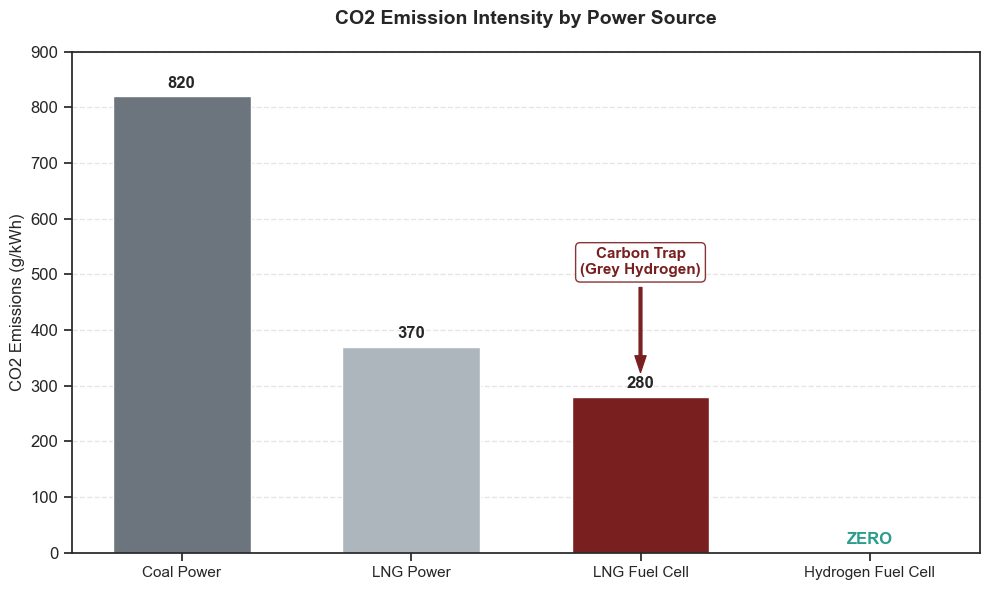

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정 (단위: gCO2/kWh, 대략적 평균치)
sources = ['Coal Power', 'LNG Power', 'LNG Fuel Cell', 'Hydrogen Fuel Cell']
emissions = [820, 370, 280, 0]  # LNG FC는 개질 과정 포함
colors = ['#6c757d', '#adb5bd', '#7A1F1F', '#2A9D8F'] # 회색톤 -> 경고색(노랑) -> 청정색(청록)

# 그래프 스타일 설정
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif'

# 1. 막대 그래프 그리기
bars = plt.bar(sources, emissions, color=colors, width=0.6)

# 2. 수치 텍스트 표시
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 10, f'{height}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        plt.text(bar.get_x() + bar.get_width()/2.0, 10, 'ZERO', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2A9D8F')

# 3. 핵심 문제 강조 (화살표 및 박스)
# LNG FC 막대 위에 "Still Emitting" 강조
plt.annotate('Carbon Trap\n(Grey Hydrogen)', 
             xy=(2, 315), xytext=(2, 500),
             arrowprops=dict(color='#7A1F1F', shrink=0.05, width=2, headwidth=8),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#7A1F1F", alpha=0.9),
             ha='center', fontsize=11, fontweight='bold', color='#7A1F1F')

# 4. 축 및 레이블 설정
plt.title('CO2 Emission Intensity by Power Source', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('CO2 Emissions (g/kWh)', fontsize=12)
plt.ylim(0, 900)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# X축 라벨 조금 더 잘 보이게
plt.xticks(fontsize=11)

plt.tight_layout()
plt.savefig('CO2_Emission.png', dpi=300)
plt.show()

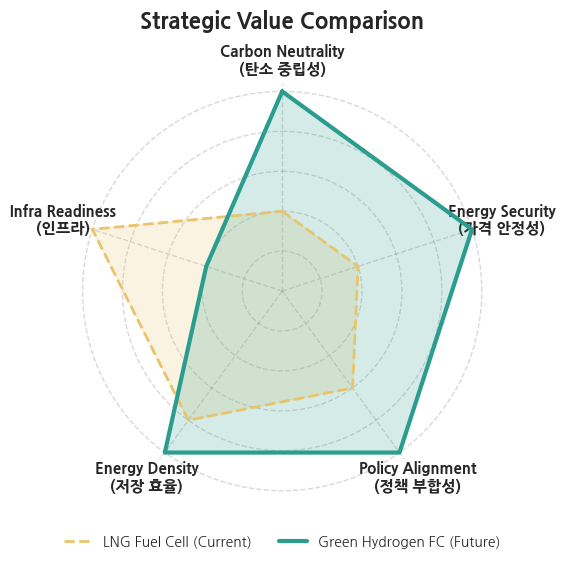

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 폰트 설정 (환경에 따라 다를 수 있음, 여기서는 나눔고딕 시도)
# 리눅스 환경(코랩 등)을 가정하여 나눔 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 설정 (5점 만점)
labels = ['Carbon Neutrality\n(탄소 중립성)', 'Energy Security\n(가격 안정성)', 
          'Policy Alignment\n(정책 부합성)', 'Energy Density\n(저장 효율)', 'Infra Readiness\n(인프라)']

# 점수 설정
stats_gas = [2, 2, 3, 4, 5]
stats_h2 = [5, 5, 5, 5, 2]

# 레이더 차트 데이터 마감 처리
stats_gas += stats_gas[:1]
stats_h2 += stats_h2[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# 그래프 스타일
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw=dict(polar=True))

# 0. 차트 회전 (첫 번째 항목이 12시 방향에 오도록)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 1. 가스 연료전지 (Gas)
ax.plot(angles, stats_gas, color='#E9C46A', linewidth=2, linestyle='--', label='LNG Fuel Cell (Current)')
ax.fill(angles, stats_gas, color='#E9C46A', alpha=0.2)

# 2. 수소 연료전지 (Hydrogen)
ax.plot(angles, stats_h2, color='#2A9D8F', linewidth=3, label='Green Hydrogen FC (Future)')
ax.fill(angles, stats_h2, color='#2A9D8F', alpha=0.2)

# 3. 축 설정
ax.set_yticklabels([]) # Y축 숫자 숨김
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')

# 테두리와 그리드 조정
ax.spines['polar'].set_visible(False)
ax.grid(color='gray', alpha=0.3, linestyle='--')

# Y축 범위 살짝 여유 있게 (라벨과 겹치지 않게)
ax.set_ylim(0, 5.2)

# 4. 범례 및 제목 (가운데 정렬을 위해 범례를 하단으로 이동)
plt.title('Strategic Value Comparison', fontsize=16, fontweight='bold', pad=40)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), 
           ncol=2, fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('radar_chart_centered.png', dpi=300, bbox_inches='tight')

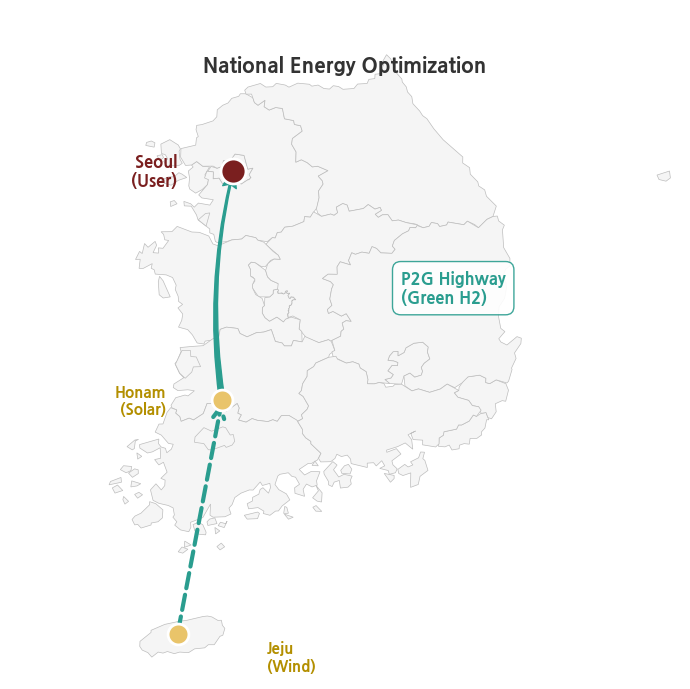

In [18]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as mpath
import numpy as np

# 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. JSON 파일 로드 (업로드된 파일 사용)
file_path = r'C:\Users\danawa\Desktop\Portfolio\Portfolio_ver1\data\SIDO_MAP_2022.json'
with open(file_path, 'r', encoding='utf-8') as f:
    geo_data = json.load(f)

# 2. 캔버스 설정
fig, ax = plt.subplots(figsize=(7, 10)) # 세로로 긴 비율
ax.set_aspect('equal')
ax.axis('off')

# 3. 지도 그리기 (GeoJSON 파싱)
for feature in geo_data['features']:
    geometry = feature['geometry']
    coords_list = geometry['coordinates']
    prop = feature['properties']
    name = prop.get('CTP_ENG_NM', '')
    
    # 지역별 색상 설정 (기본 회색, 특정 지역 강조 가능)
    # 여기서는 전체를 은은한 회색으로 통일하고 노드만 강조
    facecolor = '#F5F5F5'
    edgecolor = '#BDBDBD'
    
    if geometry['type'] == 'Polygon':
        for coords in coords_list:
            poly = patches.Polygon(coords, closed=True, fc=facecolor, ec=edgecolor, lw=0.5)
            ax.add_patch(poly)
    elif geometry['type'] == 'MultiPolygon':
        for coords in coords_list:
            for sub_coords in coords:
                poly = patches.Polygon(sub_coords, closed=True, fc=facecolor, ec=edgecolor, lw=0.5)
                ax.add_patch(poly)

# 4. 핵심 거점 좌표 설정 (수동 미세 조정으로 시각적 밸런스 맞춤)
# JSON 데이터 기반 대략적 중심 좌표
coord_seoul = (127.0, 37.55)
coord_honam = (126.9, 35.5)  # 전남/전북 중간 지점
coord_jeju = (126.5, 33.4)

# 5. 에너지 흐름선 (Energy Highway) - 화살표
# 화살표 스타일
arrow_props = dict(arrowstyle='fancy,tail_width=0.4,head_length=1.5,head_width=1.5', 
                   color='#2A9D8F', alpha=0.9, zorder=4)

# 제주 -> 호남 (점선 느낌의 연결)
ax.annotate('', xy=coord_honam, xytext=coord_jeju,
            arrowprops=dict(arrowstyle='->', color='#2A9D8F', lw=3, ls='--', mutation_scale=20))

# 호남 -> 서울 (메인 파이프라인)
# 곡선으로 연결하여 역동감 부여
ax.annotate('', xy=coord_seoul, xytext=coord_honam,
            arrowprops=dict(arrowstyle='fancy,tail_width=0.4,head_length=1.0,head_width=1.0', 
                            connectionstyle="arc3,rad=-0.1", color='#2A9D8F'))

# (1) 제주/호남 (Source: Surplus Power) - 노란색 마커
ax.plot(coord_jeju[0], coord_jeju[1], 'o', markersize=15, color='#E9C46A', markeredgecolor='white', markeredgewidth=2, zorder=5)
ax.plot(coord_honam[0], coord_honam[1], 'o', markersize=15, color='#E9C46A', markeredgecolor='white', markeredgewidth=2, zorder=5)

# 텍스트 라벨
ax.text(coord_jeju[0] + 0.8, coord_jeju[1] - 0.2, 'Jeju\n(Wind)', ha='left', va='center', fontsize=11, fontweight='bold', color='#B38F00')
ax.text(coord_honam[0] - 0.5, coord_honam[1], 'Honam\n(Solar)', ha='right', va='center', fontsize=11, fontweight='bold', color='#B38F00')


# (2) 서울 (Demand: Load Center) - 적색 마커
ax.plot(coord_seoul[0], coord_seoul[1], 'o', markersize=18, color='#7A1F1F', markeredgecolor='white', markeredgewidth=2, zorder=5)
ax.text(coord_seoul[0] - 0.5, coord_seoul[1], 'Seoul\n(User)', ha='right', va='center', fontsize=12, fontweight='bold', color='#7A1F1F')


# 6. 메시지 박스 및 제목
# P2G 설명 박스
ax.text(128.5, 36.5, "P2G Highway\n(Green H2)", ha='left', va='center', fontsize=12, fontweight='bold', color='#2A9D8F',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#2A9D8F", alpha=0.9))

# 제목
ax.text(128.0, 38.5, "National Energy Optimization", ha='center', va='center', fontsize=15, fontweight='bold', color='#333333')

# 줌 조정 (대한민국 영역에 맞게)
ax.set_xlim(125, 131)
ax.set_ylim(33, 39)

plt.tight_layout()
plt.savefig('korea_energy_map.png', dpi=300, bbox_inches='tight')
plt.show()

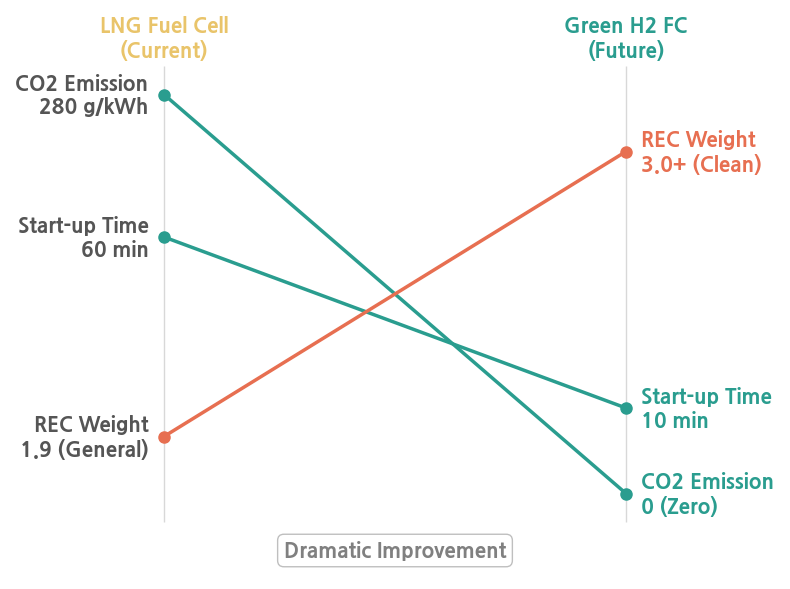

In [40]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# [폰트 설정]
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 캔버스 설정
fig, ax = plt.subplots(figsize=(8, 6))

# 배경 투명 설정
fig.patch.set_facecolor('none')
ax.patch.set_facecolor('none')

# 축 범위 및 숨김
ax.set_xlim(0, 1)
ax.set_ylim(0, 10)
ax.axis('off')

# 2. 데이터 정의 (시각적 위치 좌표 0~10)
# 실제 값이 아닌, '상대적 위치'를 지정하여 그래프가 예쁘게 나오도록 조정함
# (1) CO2 배출: 높음 -> 바닥 (280 -> 0)
y_gas_co2, y_h2_co2 = 8.5, 1.5
val_gas_co2, val_h2_co2 = "280 g/kWh", "0 (Zero)"

# (2) 기동 시간: 중간 -> 낮음 (60분 -> 10분)
y_gas_time, y_h2_time = 6.0, 3.0
val_gas_time, val_h2_time = "60 min", "10 min"

# (3) REC 가중치: 낮음 -> 높음 (1.9 -> 3.4)
y_gas_rec, y_h2_rec = 2.5, 7.5
val_gas_rec, val_h2_rec = "1.9 (General)", "3.0+ (Clean)"


# 3. 수직선 그리기 (양쪽 기둥)
ax.vlines(x=0.2, ymin=1, ymax=9, color='gray', alpha=0.3, linewidth=1) # Left (Gas)
ax.vlines(x=0.8, ymin=1, ymax=9, color='gray', alpha=0.3, linewidth=1) # Right (H2)

# 기둥 라벨 (헤더)
ax.text(0.2, 9.5, "LNG Fuel Cell\n(Current)", ha='center', va='center', fontsize=15, fontweight='bold', color='#E9C46A')
ax.text(0.8, 9.5, "Green H2 FC\n(Future)", ha='center', va='center', fontsize=15, fontweight='bold', color='#2A9D8F')


# 4. 슬로프 라인 그리기 함수
def draw_slope(name, y1, y2, val1, val2, color, line_style='-'):
    # 선 그리기
    ax.plot([0.2, 0.8], [y1, y2], color=color, linewidth=2.5, linestyle=line_style, marker='o', markersize=8)
    
    # 왼쪽 텍스트 (Gas)
    ax.text(0.18, y1, f"{name}\n{val1}", ha='right', va='center', fontsize=15, color='#555555', fontweight='bold')
    
    # 오른쪽 텍스트 (H2)
    ax.text(0.82, y2, f"{name}\n{val2}", ha='left', va='center', fontsize=15, color=color, fontweight='bold')

# (1) CO2 (회색 -> 초록색)
draw_slope("CO2 Emission", y_gas_co2, y_h2_co2, val_gas_co2, val_h2_co2, '#2A9D8F')

# (2) Start-up Time (노란색 -> 초록색)
draw_slope("Start-up Time", y_gas_time, y_h2_time, val_gas_time, val_h2_time, '#2A9D8F')

# (3) REC Weight (상승곡선, 강조!)
draw_slope("REC Weight", y_gas_rec, y_h2_rec, val_gas_rec, val_h2_rec, '#E76F51') # 강조색(살구/오렌지)


# 5. 핵심 메시지 박스
ax.text(0.5, 0.5, "Dramatic Improvement", ha='center', va='center', fontsize=15, fontweight='bold', color='gray',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.5))


plt.tight_layout()
plt.savefig('slope_chart_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

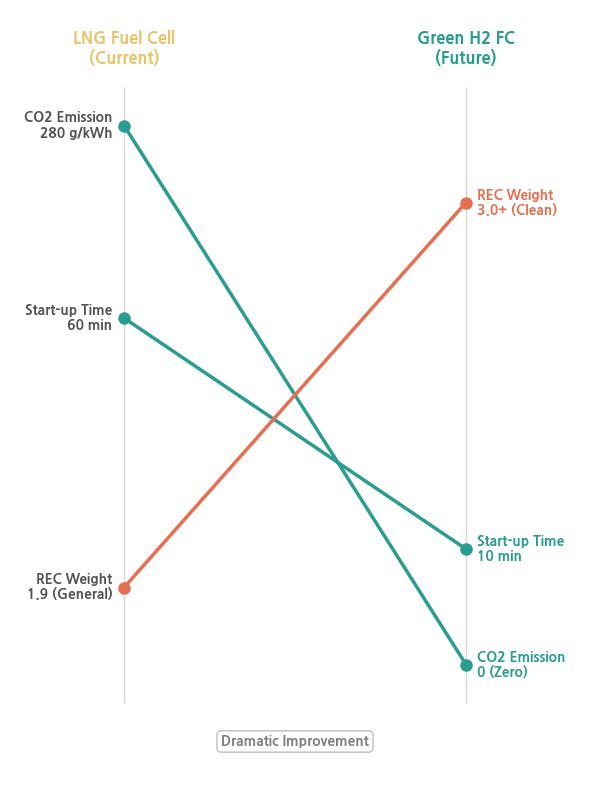

In [22]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# [폰트 설정]
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 캔버스 설정
fig, ax = plt.subplots(figsize=(6, 8))

# 배경 투명 설정
fig.patch.set_facecolor('none')
ax.patch.set_facecolor('none')

# 축 범위 및 숨김
ax.set_xlim(0, 1)
ax.set_ylim(0, 10)
ax.axis('off')

# 2. 데이터 정의 (시각적 위치 좌표 0~10)
# 실제 값이 아닌, '상대적 위치'를 지정하여 그래프가 예쁘게 나오도록 조정함
# (1) CO2 배출: 높음 -> 바닥 (280 -> 0)
y_gas_co2, y_h2_co2 = 8.5, 1.5
val_gas_co2, val_h2_co2 = "280 g/kWh", "0 (Zero)"

# (2) 기동 시간: 중간 -> 낮음 (60분 -> 10분)
y_gas_time, y_h2_time = 6.0, 3.0
val_gas_time, val_h2_time = "60 min", "10 min"

# (3) REC 가중치: 낮음 -> 높음 (1.9 -> 3.4)
y_gas_rec, y_h2_rec = 2.5, 7.5
val_gas_rec, val_h2_rec = "1.9 (General)", "3.0+ (Clean)"


# 3. 수직선 그리기 (양쪽 기둥)
ax.vlines(x=0.2, ymin=1, ymax=9, color='gray', alpha=0.3, linewidth=1) # Left (Gas)
ax.vlines(x=0.8, ymin=1, ymax=9, color='gray', alpha=0.3, linewidth=1) # Right (H2)

# 기둥 라벨 (헤더)
ax.text(0.2, 9.5, "LNG Fuel Cell\n(Current)", ha='center', va='center', fontsize=12, fontweight='bold', color='#E9C46A')
ax.text(0.8, 9.5, "Green H2 FC\n(Future)", ha='center', va='center', fontsize=12, fontweight='bold', color='#2A9D8F')


# 4. 슬로프 라인 그리기 함수
def draw_slope(name, y1, y2, val1, val2, color, line_style='-'):
    # 선 그리기
    ax.plot([0.2, 0.8], [y1, y2], color=color, linewidth=2.5, linestyle=line_style, marker='o', markersize=8)
    
    # 왼쪽 텍스트 (Gas)
    ax.text(0.18, y1, f"{name}\n{val1}", ha='right', va='center', fontsize=10, color='#555555', fontweight='bold')
    
    # 오른쪽 텍스트 (H2)
    ax.text(0.82, y2, f"{name}\n{val2}", ha='left', va='center', fontsize=10, color=color, fontweight='bold')

# (1) CO2 (회색 -> 초록색)
draw_slope("CO2 Emission", y_gas_co2, y_h2_co2, val_gas_co2, val_h2_co2, '#2A9D8F')

# (2) Start-up Time (노란색 -> 초록색)
draw_slope("Start-up Time", y_gas_time, y_h2_time, val_gas_time, val_h2_time, '#2A9D8F')

# (3) REC Weight (상승곡선, 강조!)
draw_slope("REC Weight", y_gas_rec, y_h2_rec, val_gas_rec, val_h2_rec, '#E76F51') # 강조색(살구/오렌지)


# 5. 핵심 메시지 박스
ax.text(0.5, 0.5, "Dramatic Improvement", ha='center', va='center', fontsize=10, fontweight='bold', color='gray',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.5))


plt.tight_layout()
plt.savefig('slope_chart_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

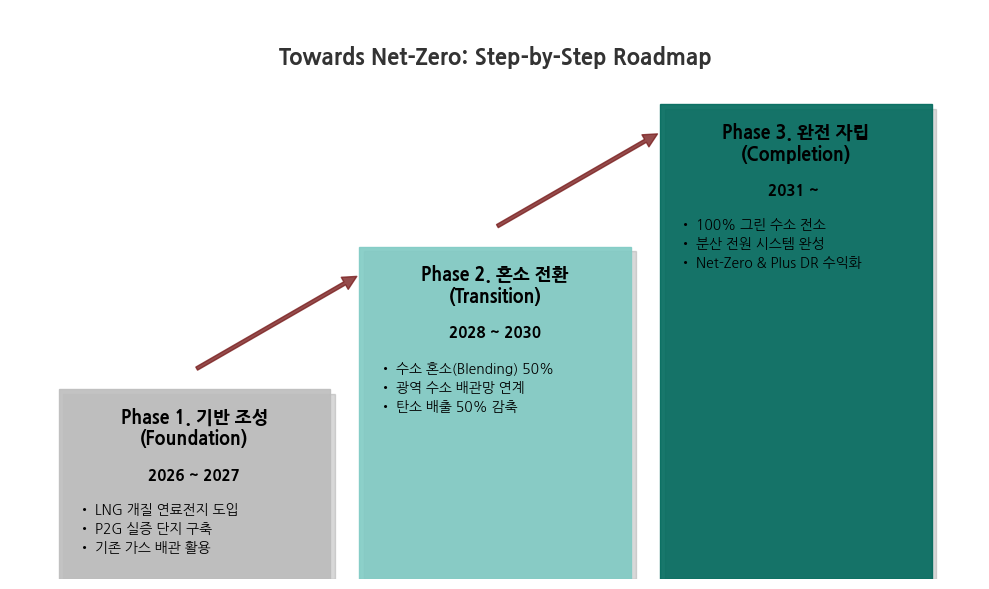

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# [폰트 설정]
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 캔버스 설정
fig, ax = plt.subplots(figsize=(10, 6))

# 배경 투명 설정
fig.patch.set_facecolor('none')
ax.patch.set_facecolor('none')

# 축 숨기기
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

# 2. 데이터 및 스타일 설정
phases = [
    {
        "title": "Phase 1. 기반 조성\n(Foundation)",
        "year": "2026 ~ 2027",
        "desc": "• LNG 개질 연료전지 도입\n• P2G 실증 단지 구축\n• 기존 가스 배관 활용",
        "color": "#BDBDBD", # 회색 (Grey)
        "x": 0.5, "y": 0, "w": 2.8, "h": 2
    },
    {
        "title": "Phase 2. 혼소 전환\n(Transition)",
        "year": "2028 ~ 2030",
        "desc": "• 수소 혼소(Blending) 50%\n• 광역 수소 배관망 연계\n• 탄소 배출 50% 감축",
        "color": "#80CBC4", # 연한 초록 (Mint)
        "x": 3.6, "y": 0, "w": 2.8, "h": 3.5
    },
    {
        "title": "Phase 3. 완전 자립\n(Completion)",
        "year": "2031 ~ ",
        "desc": "• 100% 그린 수소 전소\n• 분산 전원 시스템 완성\n• Net-Zero & Plus DR 수익화",
        "color": "#00695C", # 진한 초록 (Dark Green)
        "x": 6.7, "y": 0, "w": 2.8, "h": 5
    }
]

# 3. 로드맵 그리기 (막대 + 텍스트)
for p in phases:
    # (1) 막대 (Step)
    # 둥근 모서리 효과를 위해 FancyBboxPatch 사용 가능하지만, 깔끔하게 Rectangle로 하고 그림자 추가
    # 그림자 (Shadow)
    shadow = patches.Rectangle((p['x']+0.05, p['y']), p['w'], p['h']-0.05, color='gray', alpha=0.3)
    ax.add_patch(shadow)
    
    # 본체 (Body)
    rect = patches.Rectangle((p['x'], p['y']), p['w'], p['h'], color=p['color'], alpha=0.9)
    ax.add_patch(rect)
    
    # (2) 텍스트 (Content)
    # 제목 (Title) - 상단
    ax.text(p['x'] + p['w']/2, p['h'] - 0.4, p['title'], ha='center', va='center', 
            fontsize=13, fontweight='bold', color='black')
    
    # 연도 (Year) - 제목 아래
    ax.text(p['x'] + p['w']/2, p['h'] - 0.9, p['year'], ha='center', va='center', 
            fontsize=11, fontweight='bold', color="black")
            
    # 세부 내용 (Desc) - 중앙 ~ 하단
    # 줄바꿈 처리가 되어있으므로 그대로 출력
    ax.text(p['x'] + 0.2, p['h'] - 1.2, p['desc'], ha='left', va='top', 
            fontsize=10, color='black', linespacing=1.6)

# 4. 화살표 (Step-up Arrow)
# 단계별로 올라가는 화살표 추가하여 '성장/발전' 이미지 강조
arrow_style = dict(arrowstyle='simple, tail_width=0.5, head_width=2, head_length=2', color='#7A1F1F', alpha=0.8, mutation_scale=5) # 오렌지색 포인트
ax.add_patch(patches.FancyArrowPatch((1.9, 2.2), (3.6, 3.2), **arrow_style)) # 1 -> 2
ax.add_patch(patches.FancyArrowPatch((5.0, 3.7), (6.7, 4.7), **arrow_style)) # 2 -> 3


# 5. 핵심 메시지 (상단)
ax.text(5, 5.5, "Towards Net-Zero: Step-by-Step Roadmap", ha='center', va='center', 
        fontsize=16, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('roadmap_step_chart.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

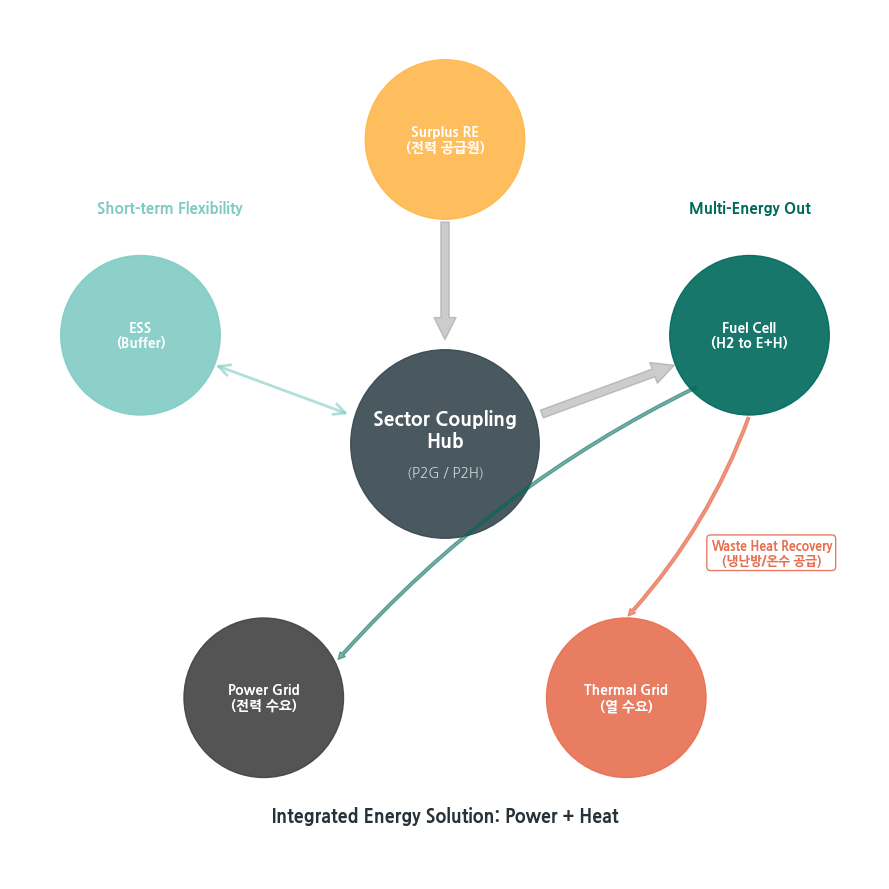

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# [폰트 설정]
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 캔버스 설정
fig, ax = plt.subplots(figsize=(9, 9))

# 배경 투명 설정
fig.patch.set_facecolor('none')
ax.patch.set_facecolor('none')

# 축 숨기기
ax.axis('off')
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

# 컬러 정의 (기존 장표와 통일 및 열 에너지 컬러 추가)
c_main = "#00695C"   # 진한 초록 (수소/전력)
c_sub = "#FFB74D"    # 오렌지 (재생에너지)
c_ess = "#80CBC4"    # 연한 초록 (ESS)
c_heat = "#E76F51"   # 다홍색 (열 에너지/Heat Sector Coupling)
c_bg = "#F5F5F5"

# 2. 중앙 섹터 커플링 허브 (Sector Coupling Hub)
hub = patches.Circle((0, 0), radius=1.3, color="#37474F", alpha=0.9, zorder=3)
ax.add_patch(hub)
ax.text(0, 0.2, "Sector Coupling\nHub", ha='center', va='center', 
        fontsize=14, fontweight='bold', color='white', zorder=4)
ax.text(0, -0.4, "(P2G / P2H)", ha='center', va='center', 
        fontsize=10, color='#CFD8DC', zorder=4)

# 3. 주변 노드 (Peripheral Nodes)
# 열 에너지(Thermal Grid)를 추가한 5개 노드 구성
nodes = [
    {"name": "Surplus RE\n(전력 공급원)", "pos": (0, 4.2), "color": c_sub},
    {"name": "ESS\n(Buffer)", "pos": (-4.2, 1.5), "color": c_ess},
    {"name": "Fuel Cell\n(H2 to E+H)", "pos": (4.2, 1.5), "color": c_main},
    {"name": "Power Grid\n(전력 수요)", "pos": (-2.5, -3.5), "color": "#424242"},
    {"name": "Thermal Grid\n(열 수요)", "pos": (2.5, -3.5), "color": c_heat}
]

for node in nodes:
    circle = patches.Circle(node['pos'], radius=1.1, color=node['color'], alpha=0.9, zorder=3)
    ax.add_patch(circle)
    ax.text(node['pos'][0], node['pos'][1], node['name'], ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white', zorder=4)

# 4. 연결 화살표 (Flow Arrows)
arrow_style = dict(arrowstyle='simple, tail_width=0.6, head_width=1.6, head_length=1.6', color='gray', alpha=0.4, zorder=1)

# (1) 재생에너지 -> 허브
ax.annotate('', xy=(0, 1.4), xytext=(0, 3.1), arrowprops=arrow_style)

# (2) 허브 <-> ESS (양방향 저장/방전)
ax.annotate('', xy=(-3.2, 1.1), xytext=(-1.3, 0.4), 
            arrowprops=dict(arrowstyle='<->', color=c_ess, alpha=0.6, lw=2, mutation_scale=20))

# (3) 허브 -> 연료전지 (수소 투입)
ax.annotate('', xy=(3.2, 1.1), xytext=(1.3, 0.4), arrowprops=arrow_style)

# (4) 연료전지 -> Power Grid (전력 생산)
ax.annotate('', xy=(-1.5, -3.0), xytext=(3.5, 0.8), 
            arrowprops=dict(arrowstyle='simple', color=c_main, alpha=0.5, connectionstyle="arc3,rad=0.1"))

# (5) 연료전지 -> Thermal Grid (열 회수: 핵심!)
ax.annotate('', xy=(2.5, -2.4), xytext=(4.2, 0.4), 
            arrowprops=dict(arrowstyle='simple', color=c_heat, alpha=0.7, connectionstyle="arc3,rad=-0.1"))

# 5. 핵심 텍스트 라벨 (전략적 가치)
ax.text(-3.8, 3.2, "Short-term Flexibility", ha='center', fontsize=11, fontweight='bold', color=c_ess)
ax.text(4.2, 3.2, "Multi-Energy Out", ha='center', fontsize=11, fontweight='bold', color=c_main)
ax.text(0, -5.2, "Integrated Energy Solution: Power + Heat", ha='center', fontsize=13, fontweight='bold', color='#263238')

# 열 섹터 커플링 강조 박스
ax.text(4.5, -1.5, "Waste Heat Recovery\n(냉난방/온수 공급)", ha='center', va='center', fontsize=9, fontweight='bold', color=c_heat,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=c_heat, alpha=0.9))

plt.tight_layout()
plt.savefig('energy_synergy_with_heat.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()